# <a id='toc1_'></a>[Sparkify Music Data EDA and Modelling](#toc0_)

❗not rerunable due to the use of self-defined `dsmodelling` python library

## dsmodelling Library
![dsmodelling workflow](../Documents/Screenshots/dsmodelling.jpg)

The `dsmodelling` library is a self-defined python package to standardize and streamline the data science workflow. It provides the functions to cover key data science steps:
1. **Data Processing**: functions for one hot encoding to prepare data for modelling.
2. **EDA**: bivariate EDA framework to explore the association between each variable and outcome.
3. **Modelling**: wrapper functions for model training, algorithm selection, model interpretation, model individual case explanation, hyperparameter tuning
4. **Deployment**: simple deployment framework using FastAPI and uvicorn.


**Table of contents**<a id='toc0_'></a>    
- [Sparkify Music Data EDA and Modelling](#toc1_)    
  - [General Data Quality Check & Quick EDA](#toc1_1_)    
  - [Data Preprocessing](#toc1_2_)    
  - [EDA - Bivariate Analysis](#toc1_3_)    
  - [Modelling](#toc1_4_)    
    - [Model Training](#toc1_4_1_)    
    - [Model Explanation & Evaluation (use Testing Dataset)](#toc1_4_2_)    
    - [Model Performance](#toc1_4_3_)    
    - [Model Fine Tuning](#toc1_4_4_)    


## Key Findings
- **Customer Analysis**: 226 customers are inludeded in the dataset from 2018-10-01 to 2018-12-03, after excluding customers with, not enough activity prior to churn no activity or no userId, 163 customers are retained for modelling.
- **Churn** customers are defined as customers who Cancellation Confirmation page in the log
- **Churn rate**: 45 out of 163 customers churned in the observation period, the overall churn rate is 27.6%
- **EDA**: A systematic bivariate EDA framework are applied to key variables to identify the association between each variable and churn status, this bivariate analysis reveals that:
    1) **association**: the churn rate of customers segmented by the value of the variable
    2) **distribution & impact**: the distribution of the variable which can interpret the impact of this segment on overall variable effect on churn
- **Modelling approach**: the modelling approachy is cohort based forward prediction. This approach aims to:
    1) simulate a 7 day look back window to extract features from customer activity, and predict the churn status in "near future" not well defined yet due to data limitation
    2) match the churn and retention customers in the same time period in the dataset
    3) zero-activity customers from retention group are excluded from modelling, considering the look back window being short
- **LightGBM model** is used as the base model, though it is not the best performing model in this limited data setting, it will reveal its strength over other models when dealing with larger datasets
- **Hyperparameter tuning** is performed using verstack, a 2.3% improvement in AUC with 10-fold cross-validation is achieved.


In [ ]:
import pandas as pd
import pickle
from ydata_profiling import ProfileReport
from summarytools import dfSummary
import os
from dsmodelling import *
%matplotlib inline
from sklearn.preprocessing import StandardScaler
import joblib
import requests
import numpy as np
# import plotly.io as pio
# import plotly.offline as py


# pio.renderers.default = 'notebook'
# py.init_notebook_mode(connected=False)


output_fd = '../Output/'
datasum_fd = output_fd + 'EDA/Summary/'
modelling_fd = output_fd + 'Modelling/'
os.makedirs('html',exist_ok=True)
os.makedirs(output_fd,exist_ok=True)
os.makedirs(datasum_fd,exist_ok=True)
os.makedirs(modelling_fd,exist_ok=True)

RETRAIN = False

## Data

* Source: Bank Marketing Data from UCI Machine Learning Repository [link](https://archive.ics.uci.edu/dataset/222/bank+marketing)

In [2]:
se_data = pd.read_csv("../Output/data_proc_eng/se_data_processed_pd.csv")

## <a id='toc1_1_'></a>[General Data Quality Check & Quick EDA](#toc0_)

In [3]:
dsum_save_dir = datasum_fd + 'DataSummary.html'
if not os.path.exists(dsum_save_dir):
    ProfileReport(se_data, explorative=True).to_file(dsum_save_dir)

In [4]:
dfSummary(se_data)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,userId[int64],Mean (sd) : 63820.6 (105656.5)min < med < max:2.0 < 113.5 < 300025.0IQR (CV) : 99956.5 (0.6),218 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjkuMiwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy8hTgPZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAAB6ElEQVR4nO3YQYrCMBiG4f8fpNhNQin0MD2Eh51D9DZF0oWKoJndwDCiNhX1k/dZm/AtXgzqOWcD3t3XqwcA91jd+oC712ZWFd5/zDnvC88Cv66G6u5127abEEJTcvk0TVt3/yZWLHXrG7UKITR93+9jjIc5F6eU1sMwNOM4VmZGqFjk5tNvZhZjPHRdtyu4vy44A/zDjylIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIWL16AP5y99rMqgVXHHPO+0ftmWPh9qu7CfWNuHvdtu0mhNCU3jFN09bdv58d69Ltt3YT6nupQghN3/f7GONh7uGU0noYhmYcx8rMnv2tWrz9nt0fG6ryExpjPHRdtys8Xj90zEwLtl/d/ZGhKj+huOwjQzXtJxQXfGqoZqb9hOIv/keFBEKFBEKFBEKFhLt+TKWU1nMvTimtT6fTysyCu88etlA4n8+rkt1mL92uuttswfZ7zvwAr/qffSUlrvQAAAAASUVORK5CYII="">",0(0.0%)
2,cancel_date[object],1. nan2. 2018-11-25 11:03:023. 2018-10-23 12:52:324. 2018-10-19 17:57:055. 2018-11-24 15:35:536. 2018-11-29 11:45:097. 2018-11-02 18:53:368. 2018-11-01 19:35:009. 2018-10-14 00:00:3710. 2018-10-11 16:19:4111. other,173 (79.4%)1 (0.5%)1 (0.5%)1 (0.5%)1 (0.5%)1 (0.5%)1 (0.5%)1 (0.5%)1 (0.5%)1 (0.5%)36 (16.5%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjkuMiwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy8hTgPZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAAD0ElEQVR4nO3cQWrbWgCG0esiQjORMAYvxovIYt8itBsTrEETMvEbNF2CP7X4nAVEgn4oirh/D/f7fUDhx943wPMQGxmxkREbGbGRERsZsZERGxmxkTmMMV7HGC973wiJr/v9/rHXxafT6fQ2z/Nxrxugs23b++Fw+G+v4KZ5no+Xy+VjWZbPPW6Axu12+7mu6/F6vb6MMfaJbYwxlmX5PJ/Pv/a4AVKve17cHwhkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZmGuP3Wae9b4TH+hv+jadt297XdT2Onc868Xjbtr2PMb72ur4NwnPZdYNw8F9mUfnzZBt7Fs9zmE6n09sYY+y5uuE5/Jjn+fg95fPexkP5zkZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERmb6HkGMseMQgufgWDgZgxcynmxkDF7IGLyQ8emDjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2MwQsZx8LJGLyQ8c5Gxq9RMtZVZKyryHhnIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjY11FxrFwMtZVZDzZyBi8kDF4IePTBxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGYMXMo6FkzF4IePJRsbghYzBCxmfPsiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjHUVGRsEMtZVZDzZyFhXkbGuIuPTBxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGYMXMo6FkzF4IePJRsbghYzBCxmfPsiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyBi8kHEsnIzBCxnvbGT8GiVjXUXGuoqMdzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjLWVWQcCydjXUXGk42MwQsZgxcyPn2QERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZExeCHjWDgZgxcyf55sxZHwL0/P5zadTqe37w3CQ23b9m5U89ymeZ6Pl8vlY1mWz0dd5Ha7/VzX9Xi9Xl/GGGJ7UtMYYyzL8nk+n389+FqvD/75/OV8ZyMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMzjfH7CNAjL/Lon8+/Ydq27X1d1+N48BGg72GNUc0TcyycjMELGX8gkBEbGbGRERsZsZERGxmxkREbGbGR+R/2VjAFEhol9gAAAABJRU5ErkJggg=="">",173(79.4%)
3,churn[bool],1. False2. True,173 (79.4%)45 (20.6%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjkuMiwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy8hTgPZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABMklEQVR4nO3bwYnDMBhE4dFiwuYiYQwuxkVssVuEujHGOiQhF+1ha8j8Ar+vAQnyEnDwpN67AIck6S7pFn0RWLx778+ow6dlWX5yznPUBeDTWjtSSr9RwU0553nbtmcp5RVxAXic5/lda533fb9JiolNkkopr3VdHxEXgNU98vCvyMNxLcQGG2KDDbHBhthgQ2ywITbYEBtsiA02xAYbYoMNscGG2GBDbLAhNthM0v+LddEXwWeN8BlPrbWj1jor+MU6fF5r7ZD0jjqfwcu1hA5eElM+uIzwyxb6bYNP+JQvel4Gn9Ap3wjzMviMMOXjKfgi+FMXNsQGG2KDDbHBhthgQ2ywITbYEBtsiA02xAYbYoMNscGG2GBDbLAhNtiETvlGmJfBJ3zKFz0vgw+DF9j8AQpbat+srJxBAAAAAElFTkSuQmCC"">",0(0.0%)
4,start_date[object],1. 2018-10-262. 2018-10-103. 2018-10-134. 2018-10-175. 2018-10-056. 2018-11-107. 2018-10-208. 2018-10-079. 2018-10-0810. 2018-11-0711. other,23 (10.6%)19 (8.7%)13 (6.0%)12 (5.5%)10 (4.6%)10 (4.6%)8 (3.7%)8 (3.7%)8 (3.7%)8 (3.7%)99 (45.4%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAA

## <a id='toc1_2_'></a>[Data Preprocessing for EDA](#toc0_)

In [5]:
# age_bins = [18, 30, 40, 50, 60, 70, 80, float('inf')]
# age_labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
# se_data_eda['AgeBand'] = pd.cut(se_data_eda['age'], bins=age_bins, labels=age_labels, right=False)
# month_lookup_df = pd.DataFrame({
#     'month':['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'],
#     'month_num':[1,2,3,4,5,6,7,8,9,10,11,12]
# })
# se_data_eda = se_data_eda.merge(month_lookup_df)
# se_data_eda.month_num.value_counts()
# dur_bins = [0, 60, 600, float('inf')]
# dur_labels = ['<1min', '1min-10min', '>10min']
# se_data_eda['DurationBand'] = pd.cut(se_data_eda['duration'], bins=dur_bins, labels=dur_labels, right=True)
# se_data_eda.DurationBand.value_counts()
# cam_bins = [0, 5, 10, 20, 30, float('inf')]
# cam_labels = ['1-5','6-10','11-20','21-30','30+']
# se_data_eda['CampaignBand'] = pd.cut(se_data_eda['campaign'], bins=cam_bins, labels=cam_labels, right=True)
# se_data_eda.CampaignBand.value_counts()
# se_data_eda['PreviousBand'] = pd.cut(se_data_eda['previous'], bins=cam_bins, labels=cam_labels, right=True)
# se_data_eda.PreviousBand.value_counts()
# bal_bins = [-1, 0, 500, 1000, 10000, 20000, float('inf')]
# bal_labels = ['b1 0','b2 <=500','b3 <=1000','b4 <=10000','b5 <=20000','b6 20000+']
# se_data_eda['BalanceBand'] = pd.cut(se_data_eda['balance'], bins=bal_bins, labels=bal_labels, right=True)
# se_data_eda.BalanceBand.value_counts()
# se_data_eda.loc[se_data_eda.poutcome.isnull(),'poutcome'] = 'missing'
# se_data_eda.poutcome.value_counts()
# poutcome_values = ['missing','other','failure','success']
# color_map_dict_poutcome = {
#     "missing": "#838B8B",
#     "other": "#8B795E",
#     "failure": "#CD2626",
#     "success": "#009ACD"
# }

In [51]:
se_data_eda = se_data.copy()

thu_bins = [-1, 0.5, 5, 10, float('inf')]
thu_labels = ['0','1-5','6-10','11+']
se_data_eda['ThumbsUpBand'] = pd.cut(se_data_eda['act_page_thumbs_up'], bins=thu_bins, labels=thu_labels, right=True)

thd_bins = [-1, 0.5, 2, float('inf')]
thd_labels = ['0','1-2','3+']
se_data_eda['ThumbsDownBand'] = pd.cut(se_data_eda['act_page_thumbs_down'], bins=thd_bins, labels=thd_labels, right=True)


playlist_bins = [-1, 0, 10, 20, float('inf')]
playlist_labels = ['0','1-10','10-20','21+']
se_data_eda['PlaylistBand'] = pd.cut(se_data_eda['act_page_add_to_playlist'], bins=playlist_bins, labels=playlist_labels, right=True)

friend_bins = [-1, 0, 10, float('inf')]
friend_labels = ['0','1-10','11+']
se_data_eda['FriendBand'] = pd.cut(se_data_eda['act_page_add_friend'], bins=friend_bins, labels=friend_labels, right=True)

active_bins = [-1, 0, 3, float('inf')]
active_labels = ['0','1-3','4-7']
se_data_eda['ActiveBand'] = pd.cut(se_data_eda['act_days_active'], bins=active_bins, labels=active_labels, right=True)

se_data_eda['y'] = se_data_eda['churn'].map({True:'churn',False:'not_churn'})
y_values = ['churn','not_churn']
color_map_dict_y = {
    "churn": "#CD2626",
    "not_churn": "#009ACD"
}

## <a id='toc1_3_'></a>[EDA - Bivariate Analysis](#toc0_)


In [7]:
se_data_eda.columns

Index(['userId', 'cancel_date', 'churn', 'start_date', 'end_date',
       'has_activity', 'psn_gender', 'psn_city', 'psn_state',
       'acct_day_since_reg', 'psn_multi_city', 'psn_multi_state',
       'acct_last_level', 'acct_multiple_levels', 'act_page_about',
       'act_page_add_friend', 'act_page_add_to_playlist', 'act_page_downgrade',
       'act_page_error', 'act_page_help', 'act_page_home', 'act_page_logout',
       'act_page_nextsong', 'act_page_roll_advert', 'act_page_save_settings',
       'act_page_settings', 'act_page_submit_downgrade',
       'act_page_submit_upgrade', 'act_page_thumbs_down', 'act_page_thumbs_up',
       'act_page_upgrade', 'total_page_visits', 'unique_page_types',
       'session_count', 'session_avg_pages', 'act_days_active',
       'prf_top20artist_count', 'prf_top20artist_any',
       'prf_top100artist_count', 'prf_top100artist_any',
       'prf_unique_artist_count', 'prf_unique_artist_any',
       'prf_top100song_count', 'prf_top100song_any', 'prf_to

In [8]:
bivariateAnalysisDist(se_data_eda, 'psn_gender', 'y','Gender vs Churn', 500, y_values, color_map_dict_y)

In [9]:
bivariateAnalysisDist(se_data_eda, 'psn_multi_city', 'y','City vs Churn', 500, y_values, color_map_dict_y)

In [10]:
bivariateAnalysisDist(se_data_eda, 'psn_multi_state', 'y','State vs Churn', 500, y_values, color_map_dict_y)

In [11]:
bivariateAnalysisDist(se_data_eda, 'acct_last_level', 'y','Account Last Level vs Churn', 500, y_values, color_map_dict_y)


In [12]:
bivariateAnalysisDist(se_data_eda, 'acct_multiple_levels', 'y','Account Multiple Levels vs Churn', 500, y_values, color_map_dict_y)


In [13]:
bivariateAnalysisDist(se_data_eda, 'ThumbsUpBand', 'y','Thumbs Up vs Churn', 500, y_values, color_map_dict_y)


In [14]:
bivariateAnalysisDist(se_data_eda, 'ThumbsDownBand', 'y','Thumbs Down vs Churn', 500, y_values, color_map_dict_y)


In [52]:
bivariateAnalysisDist(se_data_eda, 'PlaylistBand', 'y','Add to Playlist page count vs Churn', 500, y_values, color_map_dict_y)


In [53]:
bivariateAnalysisDist(se_data_eda, 'FriendBand', 'y','Add Friend page count vs Churn', 500, y_values, color_map_dict_y)

In [54]:
bivariateAnalysisDist(se_data_eda, 'ActiveBand', 'y','Days Active vs Churn', 500, y_values, color_map_dict_y)

In [15]:
bivariateAnalysisDist(se_data_eda, 'prf_top20artist_any', 'y','Top 20 Artist vs Churn', 500, y_values, color_map_dict_y)


In [16]:
bivariateAnalysisDist(se_data_eda, 'prf_top100artist_any', 'y','Top 100 Artist vs Churn', 500, y_values, color_map_dict_y)


In [17]:
bivariateAnalysisDist(se_data_eda, 'prf_unique_artist_any', 'y','Unique Artist vs Churn', 500, y_values, color_map_dict_y)


In [18]:
bivariateAnalysisDist(se_data_eda, 'prf_top100song_any', 'y','Top 100 Song vs Churn', 500, y_values, color_map_dict_y)


In [19]:
bivariateAnalysisDist(se_data_eda, 'prf_top1000song_any', 'y','Top 1000 Song vs Churn', 500, y_values, color_map_dict_y)


In [20]:
bivariateAnalysisDist(se_data_eda, 'prf_unique_song_any', 'y','Unique Song vs Churn', 500, y_values, color_map_dict_y)


## <a id='toc1_4_'></a>[Modelling](#toc0_)

### <a id='toc1_4_1_'></a>[Model Training](#toc0_)

In [21]:
se_data.columns

Index(['userId', 'cancel_date', 'churn', 'start_date', 'end_date',
       'has_activity', 'psn_gender', 'psn_city', 'psn_state',
       'acct_day_since_reg', 'psn_multi_city', 'psn_multi_state',
       'acct_last_level', 'acct_multiple_levels', 'act_page_about',
       'act_page_add_friend', 'act_page_add_to_playlist', 'act_page_downgrade',
       'act_page_error', 'act_page_help', 'act_page_home', 'act_page_logout',
       'act_page_nextsong', 'act_page_roll_advert', 'act_page_save_settings',
       'act_page_settings', 'act_page_submit_downgrade',
       'act_page_submit_upgrade', 'act_page_thumbs_down', 'act_page_thumbs_up',
       'act_page_upgrade', 'total_page_visits', 'unique_page_types',
       'session_count', 'session_avg_pages', 'act_days_active',
       'prf_top20artist_count', 'prf_top20artist_any',
       'prf_top100artist_count', 'prf_top100artist_any',
       'prf_unique_artist_count', 'prf_unique_artist_any',
       'prf_top100song_count', 'prf_top100song_any', 'prf_to

In [22]:
se_data.churn.value_counts()
se_data = se_data.set_index('userId')
print(se_data.dtypes)
print(se_data.columns)
exclude_cols = ['cancel_date','start_date','end_date','has_activity','psn_city','psn_state']
se_data_mdl = se_data[se_data['has_activity']].drop(columns=exclude_cols).copy()
se_data_mdl['churn'] = se_data_mdl['churn'].astype(int)
print(se_data_mdl.shape)
print(se_data_mdl.columns)

cancel_date                   object
churn                           bool
start_date                    object
end_date                      object
has_activity                    bool
psn_gender                    object
psn_city                      object
psn_state                     object
acct_day_since_reg             int64
psn_multi_city                  bool
psn_multi_state                 bool
acct_last_level               object
acct_multiple_levels            bool
act_page_about                 int64
act_page_add_friend            int64
act_page_add_to_playlist       int64
act_page_downgrade             int64
act_page_error                 int64
act_page_help                  int64
act_page_home                  int64
act_page_logout                int64
act_page_nextsong              int64
act_page_roll_advert           int64
act_page_save_settings         int64
act_page_settings              int64
act_page_submit_downgrade      int64
act_page_submit_upgrade        int64
a

In [23]:
model_ready_data = pd.get_dummies(se_data_mdl)
print(model_ready_data.shape)
print(model_ready_data.columns)
model_ready_data = stratifiedSampling(model_ready_data,stratify_col='churn', test_size=0.2, random_seed=42)
train = model_ready_data[model_ready_data.train_ind == True].drop(columns = ['train_ind'])
test = model_ready_data[model_ready_data.train_ind == False].drop(columns = ['train_ind'])
y_train = train[['churn']].reset_index(drop=True)
y_test = test[['churn']].reset_index(drop=True)
X_train = train.drop(columns='churn')
X_test = test.drop(columns='churn')

(163, 43)
Index(['churn', 'acct_day_since_reg', 'psn_multi_city', 'psn_multi_state',
       'acct_multiple_levels', 'act_page_about', 'act_page_add_friend',
       'act_page_add_to_playlist', 'act_page_downgrade', 'act_page_error',
       'act_page_help', 'act_page_home', 'act_page_logout',
       'act_page_nextsong', 'act_page_roll_advert', 'act_page_save_settings',
       'act_page_settings', 'act_page_submit_downgrade',
       'act_page_submit_upgrade', 'act_page_thumbs_down', 'act_page_thumbs_up',
       'act_page_upgrade', 'total_page_visits', 'unique_page_types',
       'session_count', 'session_avg_pages', 'act_days_active',
       'prf_top20artist_count', 'prf_top20artist_any',
       'prf_top100artist_count', 'prf_top100artist_any',
       'prf_unique_artist_count', 'prf_unique_artist_any',
       'prf_top100song_count', 'prf_top100song_any', 'prf_top1000song_count',
       'prf_top1000song_any', 'prf_unique_song_count', 'prf_unique_song_any',
       'psn_gender_F', 'psn_gende

In [24]:
## Model Selection
model_sel_data = X_train
model_saved_path = modelling_fd + 'model_sel_dict.pickle'
model_sel_dict = dict()
model_sel_dict['lgb'] = runModels(model_sel_data.reset_index(drop=True), y_train, models['lgb'], model_sel_data)

100%|██████████| 10/10 [00:02<00:00,  4.28it/s]


### <a id='toc1_4_2_'></a>[Model Explanation & Evaluation (use Testing Dataset)](#toc0_)

In [25]:
import shap

shap_save_dir = modelling_fd + 'shap_values.pickle'
shap_model = model_sel_dict['lgb'].model  # Access model attribute from ModelResult

if (os.path.exists(shap_save_dir)) & (not RETRAIN):
    shap_values = pickle.load(open(shap_save_dir, 'rb'))
else:
    shap.initjs()
    explainer = shap.Explainer(shap_model)
    shap_values = explainer(X_test)
    pickle.dump(shap_values, open(shap_save_dir, 'wb'))

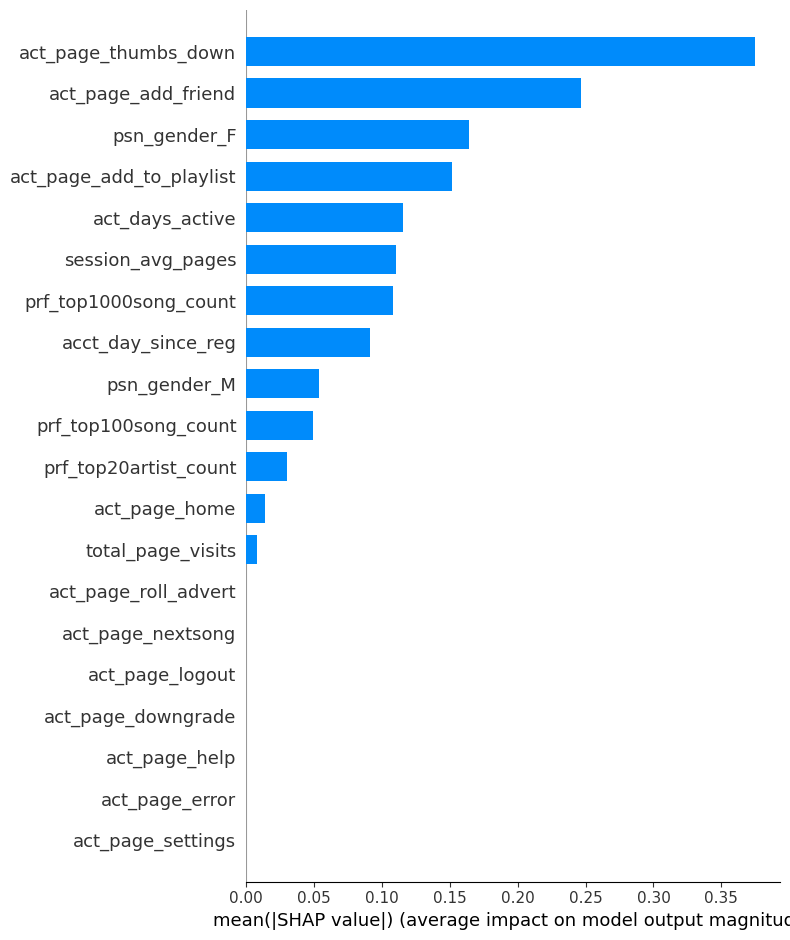

In [26]:
plotShapImportanceBar(shap_values, X_test)

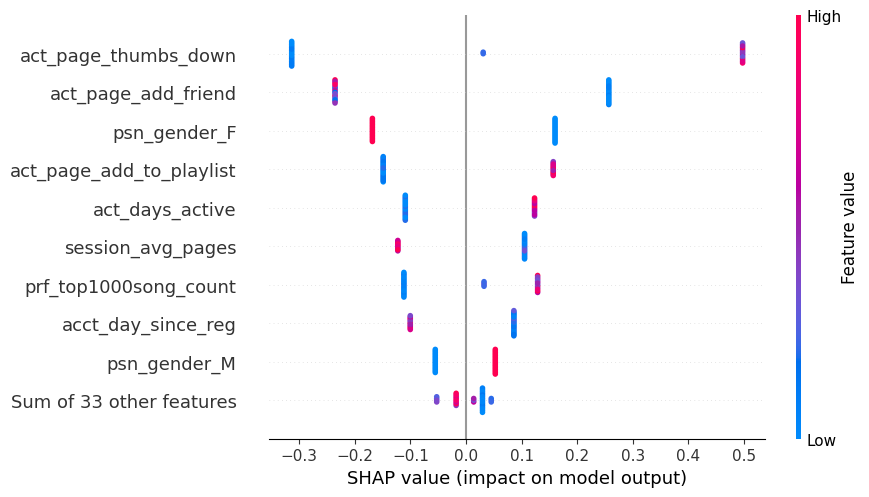

In [27]:

# Running the functions
plotBeeswarmTopFeatures(shap_values, 10)


In [28]:
# Call the function
plotShapScatterPlotly(shap_values, X_test, y_test)


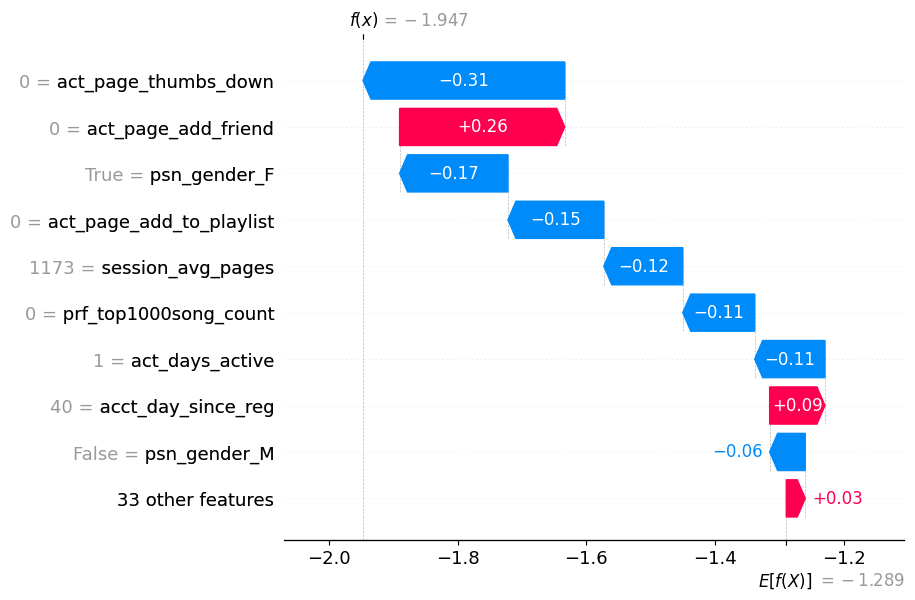

In [29]:
plotShapWaterFall(sample_idx=1, shap_values=shap_values, test=X_test)


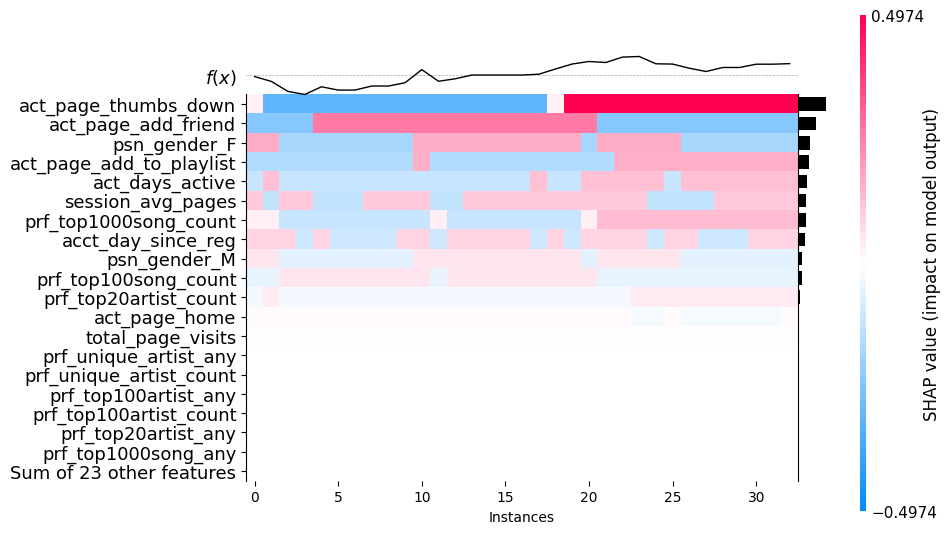

In [30]:
plotShapHeatmap(shap_values,top_n=20)


### <a id='toc1_4_3_'></a>[Model Performance](#toc0_)

In [31]:
plotRocAUCPlotly(shap_model, X_train, y_train, X_test, y_test)

In [32]:
metrics_df = getModelMetrics(shap_model, X_test, y_test)
metrics_df

,Metric,Value (%)
0,Accuracy,78.7879
1,Precision,0.0000
2,Sensitivity (Recall),0.0000
3,Specificity,100.0000
4,F1 Score,0.0000
5,AUC,78.2967


### <a id='toc1_4_4_'></a>[Model Fine Tuning](#toc0_)

In [33]:
model_tuning_path = modelling_fd + 'model_tuned_dict.pickle'
if (os.path.exists(model_tuning_path)) & (not RETRAIN):
    model_tuned_dict = pickle.load(open(model_tuning_path,'rb'))
else:
    model_tuned_dict = dict()
    model_tuned_dict['before_tuning'] = model_sel_dict['lgb']
    model_tuned_dict['after_tuning'] = fine_tune_lgb(X_train, y_train)
    pickle.dump(model_tuned_dict, open(model_tuning_path,'wb'))

In [34]:
compareAUCs(model_tuned_dict, [0,1])

In [35]:
rocCurvePlotly(model_tuned_dict, X_test, y_test, run_type='Testing')

## <a id='toc1_5_'></a>[Deployment](#toc0_)

### Steps

1. Create a deployment folder and generate test data for deployment
2. Choose deployment model
3. Deploy model through local fastAPI
4. Create a Dockerfile for Google Cloud Run Deployment
5. Deploy model to Google Cloud Run and test the service

,acct_day_since_reg,psn_multi_city,psn_multi_state,acct_multiple_levels,act_page_about,act_page_add_friend,act_page_add_to_playlist,act_page_downgrade,act_page_error,act_page_help,...,prf_top100song_count,prf_top100song_any,prf_top1000song_count,prf_top1000song_any,prf_unique_song_count,prf_unique_song_any,psn_gender_F,psn_gender_M,acct_last_level_free,acct_last_level_paid
userId,,,,,,,,,,,,,,,,,,,,,
30,34,False,False,True,1,3,5,0,0,1,...,18,True,60,True,35,True,False,True,True,False
4,48,True,False,True,1,14,12,4,2,6,...,50,True,130,True,73,True,False,True,False,True
101,53,True,False,True,1,9,37,15,0,3,...,84,True,240,True,149,True,False,True,False,True
88,63,False,True,True,1,2,8,4,0,2,...,24,True,57,True,26,True,True,False,False,True
95,33,True,False,True,0,0,0,0,1,0,...,5,True,13,True,14,True,True,False,True,False


In [43]:
with open("deployment/deployed_model.pkl", "wb") as f:
    joblib.dump(model_tuned_dict['after_tuning'].model, f)  # Access model attribute from ModelResult
X_test.head().to_csv('./deployment/test_data.csv', index=False)

In [46]:
# run in terminal
# Streamlit UI demo to create url for local fastAPI call
###########################
# streamlit run streamlit_app.py


# Local FastAPI
###########################
# uvicorn fastapi_app:app --host=0.0.0.0 --port=8080
port = "8080"
url = f"http://localhost:{port}/predict?acct_day_since_reg=31&psn_multi_city=True&psn_multi_state=True&acct_multiple_levels=True&act_page_about=0&act_page_add_friend=4&act_page_add_to_playlist=3&act_page_downgrade=2&act_page_error=1&act_page_help=2&act_page_home=6&act_page_logout=1&act_page_nextsong=158&act_page_roll_advert=6&act_page_save_settings=0&act_page_settings=0&act_page_submit_downgrade=1&act_page_submit_upgrade=1&act_page_thumbs_down=1&act_page_thumbs_up=10&act_page_upgrade=2&total_page_visits=198&unique_page_types=14&session_count=3.0&session_avg_pages=1323.7727272727273&act_days_active=4.0&prf_top20artist_count=17&prf_top20artist_any=True&prf_top100artist_count=43&prf_top100artist_any=True&prf_unique_artist_count=0&prf_unique_artist_any=False&prf_top100song_count=19&prf_top100song_any=True&prf_top1000song_count=45&prf_top1000song_any=True&prf_unique_song_count=14&prf_unique_song_any=True&psn_gender_F=False&psn_gender_M=True&acct_last_level_free=False&acct_last_level_paid=True"
response = requests.get(url)
# Check the response
print("Status code:", response.status_code)
try:
    print("JSON response:", response.json())
except requests.exceptions.JSONDecodeError:
    print("⚠️ Response is not JSON. Raw text:")
    print(response.text)


Status code: 200
JSON response: {'success': True, 'prediction (%)': 4.66}
